In [1]:
!pip install pmdarima

In [2]:
# Created based on the lessons of Karina Data Scientist YouTube @https://www.youtube.com/@karinadatascientist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

In [3]:
df = pd.read_csv('rohitsahoo-sales-forecasting.csv')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format = '%d/%m/%Y')

In [7]:
monthly_sales = df.groupby(pd.Grouper(key = 'Order Date', freq = 'ME'))['Sales'].sum()

In [8]:
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

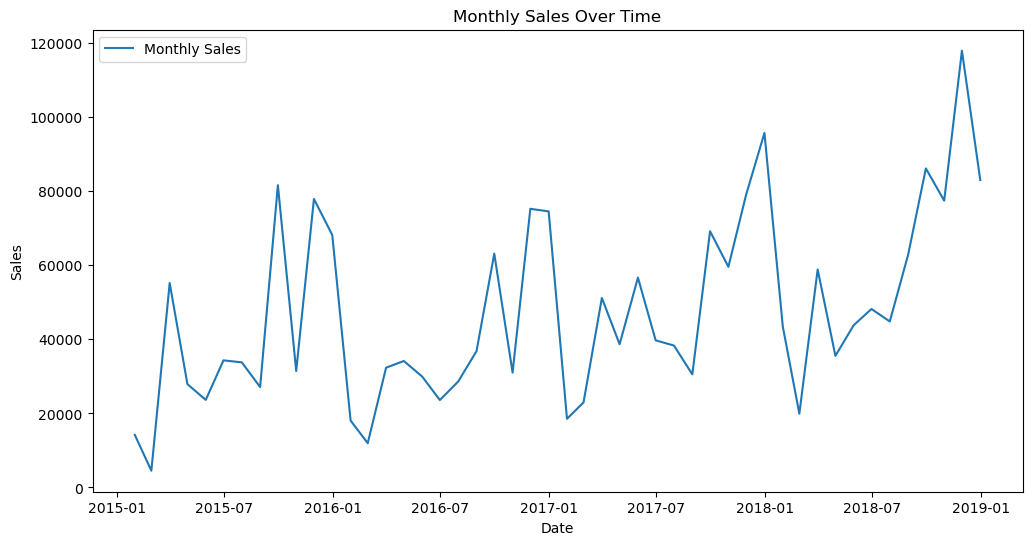

In [10]:
plt.figure(figsize = (12, 6))
plt.plot(monthly_sales, label = 'Monthly Sales')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

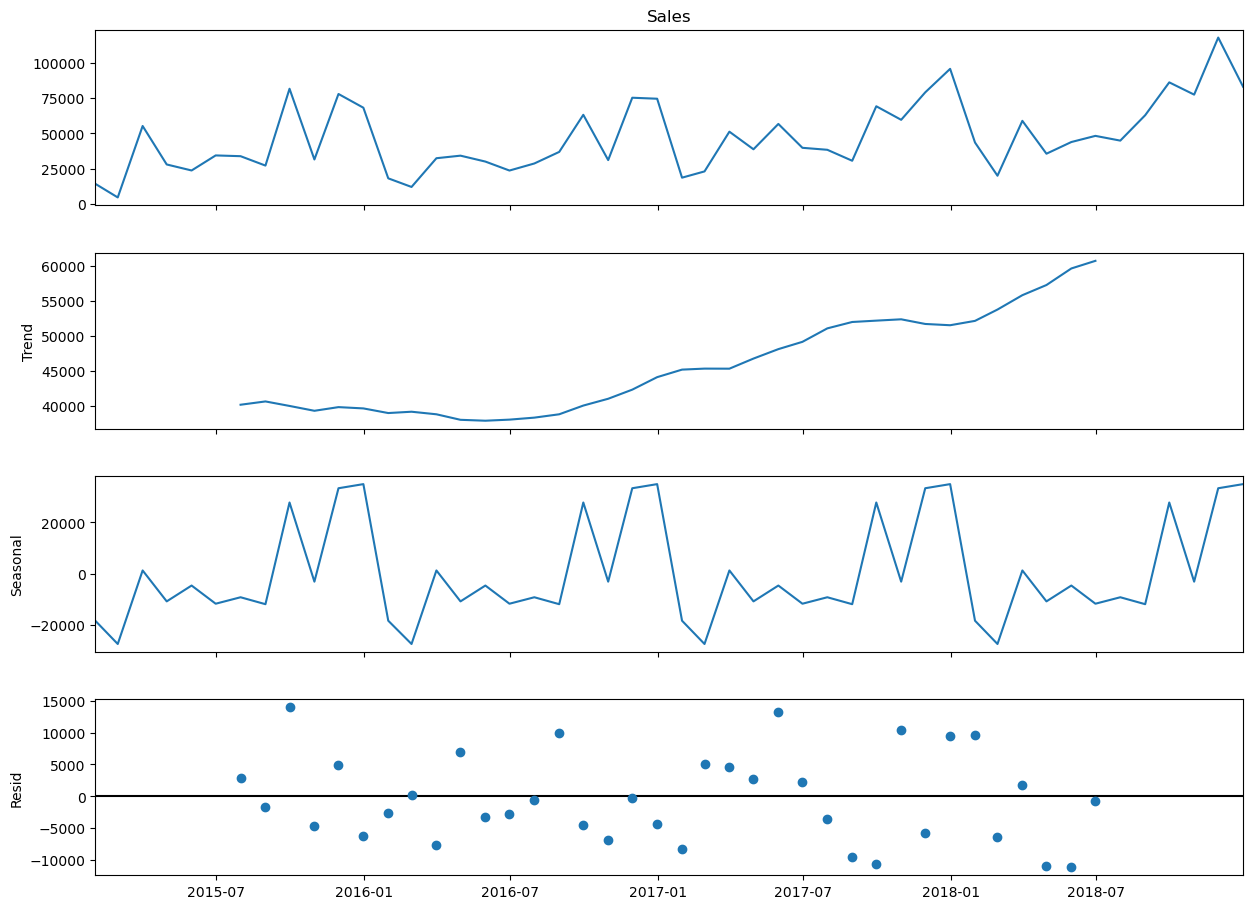

In [11]:
decomposition = seasonal_decompose(monthly_sales, model = 'addictive')
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [27]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('Augmented Dickey-Fuller Test Results:')
    print('ADF Statistics:', result[0])
    print('P-value', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f"\t{key}: {value}")
    return result[1] < 0.05
    
is_stationary = check_stationarity(monthly_sales)
print(f"\nTime series is {'stationary' if is_stationary else 'non-stationary'}.")

Augmented Dickey-Fuller Test Results:
ADF Statistics: -4.416136761430768
P-value 0.00027791039276670677
Critical Values:
	1%: -3.5778480370438146
	5%: -2.925338105429433
	10%: -2.6007735310095064

Time series is stationary.


In [28]:
auto_model = auto_arima(
    monthly_sales,
    start_p = 0,
    start_q = 0,
    max_p = 5,
    max_q = 5,
    n = 12,
    seasonal = True,
    d = None,
    trace = True,
    error_action = 'ignore',
    suppress_warnigns = True,
    stepwise = True
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1096.560, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1089.579, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1084.886, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1094.708, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1086.890, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1087.498, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1087.606, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1083.594, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1084.585, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1084.690, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1088.071, Time=0.12 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1086.217, Time=0.20 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.417 seconds


In [36]:
model = ARIMA(
    monthly_sales,
    order = auto_model.order,
    seasonal_order = auto_model.seasonal_order
) 
results = model.fit()

In [37]:
forecast_periods = 12
forecast = results.get_forecast(steps = forecast_periods)
mean_forecast = forecast.predicted_mean

In [38]:
conf_int_99 = forecast.conf_int(alpha = 0.01)
conf_int_95 = forecast.conf_int(alpha = 0.05)
conf_int_90 = forecast.conf_int(alpha = 0.10)
conf_int_80 = forecast.conf_int(alpha = 0.20)
conf_int_70 = forecast.conf_int(alpha = 0.30)

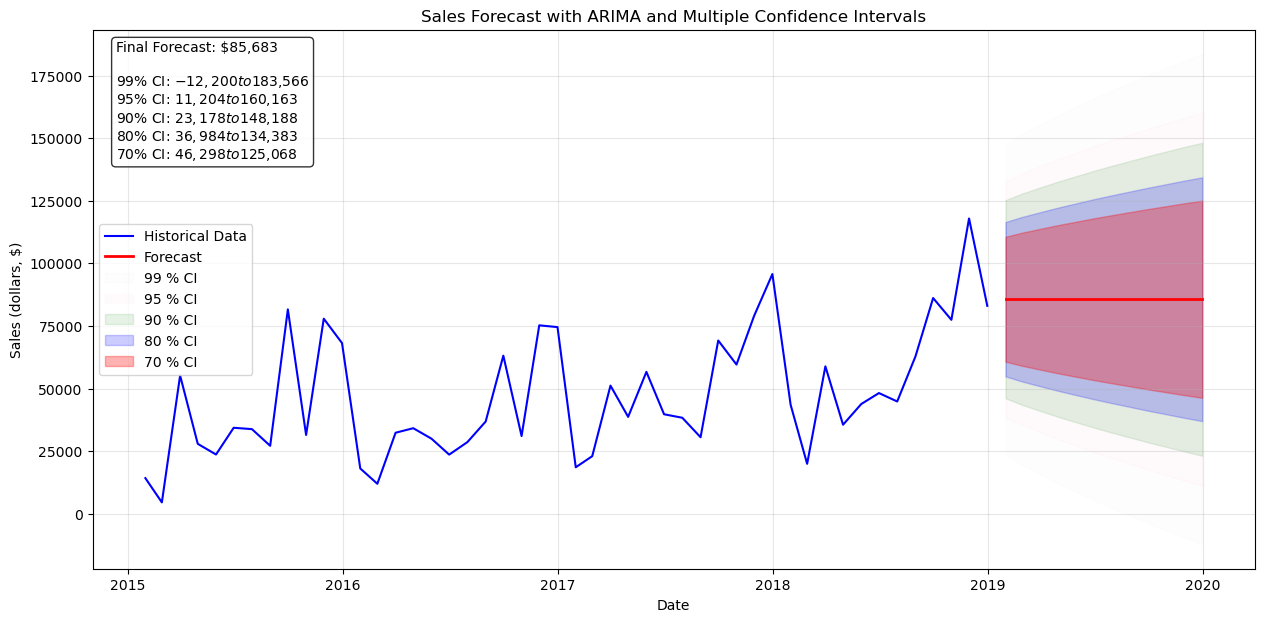

In [40]:
plt.figure(figsize = (15, 7))
plt.plot(monthly_sales, label = 'Historical Data', color = 'blue')
plt.plot(mean_forecast, label = 'Forecast', color = 'red', linewidth = 2)
plt.fill_between(
    mean_forecast.index,
    conf_int_99.iloc[:, 0],
    conf_int_99.iloc[:, 1],
    color = 'violet',
    alpha = 0.01,
    label = '99 % CI'
)
plt.fill_between(
    mean_forecast.index,
    conf_int_95.iloc[:, 0],
    conf_int_95.iloc[:, 1],
    color = 'pink',
    alpha = 0.05,
    label = '95 % CI'
)
plt.fill_between(
    mean_forecast.index,
    conf_int_90.iloc[:, 0],
    conf_int_90.iloc[:, 1],
    color = 'green',
    alpha = 0.1,
    label = '90 % CI'
)
plt.fill_between(
    mean_forecast.index,
    conf_int_80.iloc[:, 0],
    conf_int_80.iloc[:, 1],
    color = 'blue',
    alpha = 0.2,
    label = '80 % CI'
)
plt.fill_between(
    mean_forecast.index,
    conf_int_70.iloc[:, 0],
    conf_int_70.iloc[:, 1],
    color = 'red',
    alpha = 0.3,
    label = '70 % CI'
)
plt.title('Sales Forecast with ARIMA and Multiple Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Sales (dollars, $)')
plt.legend()
plt.grid(True, alpha = 0.3)
last_forecast = mean_forecast.iloc[-1]
ranges_99_lower = conf_int_99.iloc[-1, 0]
ranges_99_upper = conf_int_99.iloc[-1, 1]
ranges_95_lower = conf_int_95.iloc[-1, 0]
ranges_95_upper = conf_int_95.iloc[-1, 1]
ranges_90_lower = conf_int_90.iloc[-1, 0]
ranges_90_upper = conf_int_90.iloc[-1, 1]
ranges_80_lower = conf_int_80.iloc[-1, 0]
ranges_80_upper = conf_int_80.iloc[-1, 1]
ranges_70_lower = conf_int_70.iloc[-1, 0]
ranges_70_upper = conf_int_70.iloc[-1, 1]
info_text = f'Final Forecast: ${last_forecast:,.0f}\n\n' \
            f'99% CI: ${ranges_99_lower:,.0f} to ${ranges_99_upper:,.0f}\n' \
            f'95% CI: ${ranges_95_lower:,.0f} to ${ranges_95_upper:,.0f}\n' \
            f'90% CI: ${ranges_90_lower:,.0f} to ${ranges_90_upper:,.0f}\n' \
            f'80% CI: ${ranges_80_lower:,.0f} to ${ranges_80_upper:,.0f}\n' \
            f'70% CI: ${ranges_70_lower:,.0f} to ${ranges_70_upper:,.0f}'
plt.text(
    0.02, 
    0.98, 
    info_text,
    transform = plt.gca().transAxes,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8)
)
plt.show()